TASK 3: FORECAST FUTURE MARKET TRENDS
TSLA data: 2512 rows
ARIMA trained. AIC: 3935.38

Current Price: $419.77
12-Month Forecast: $418.08
Projected Change: -0.4%


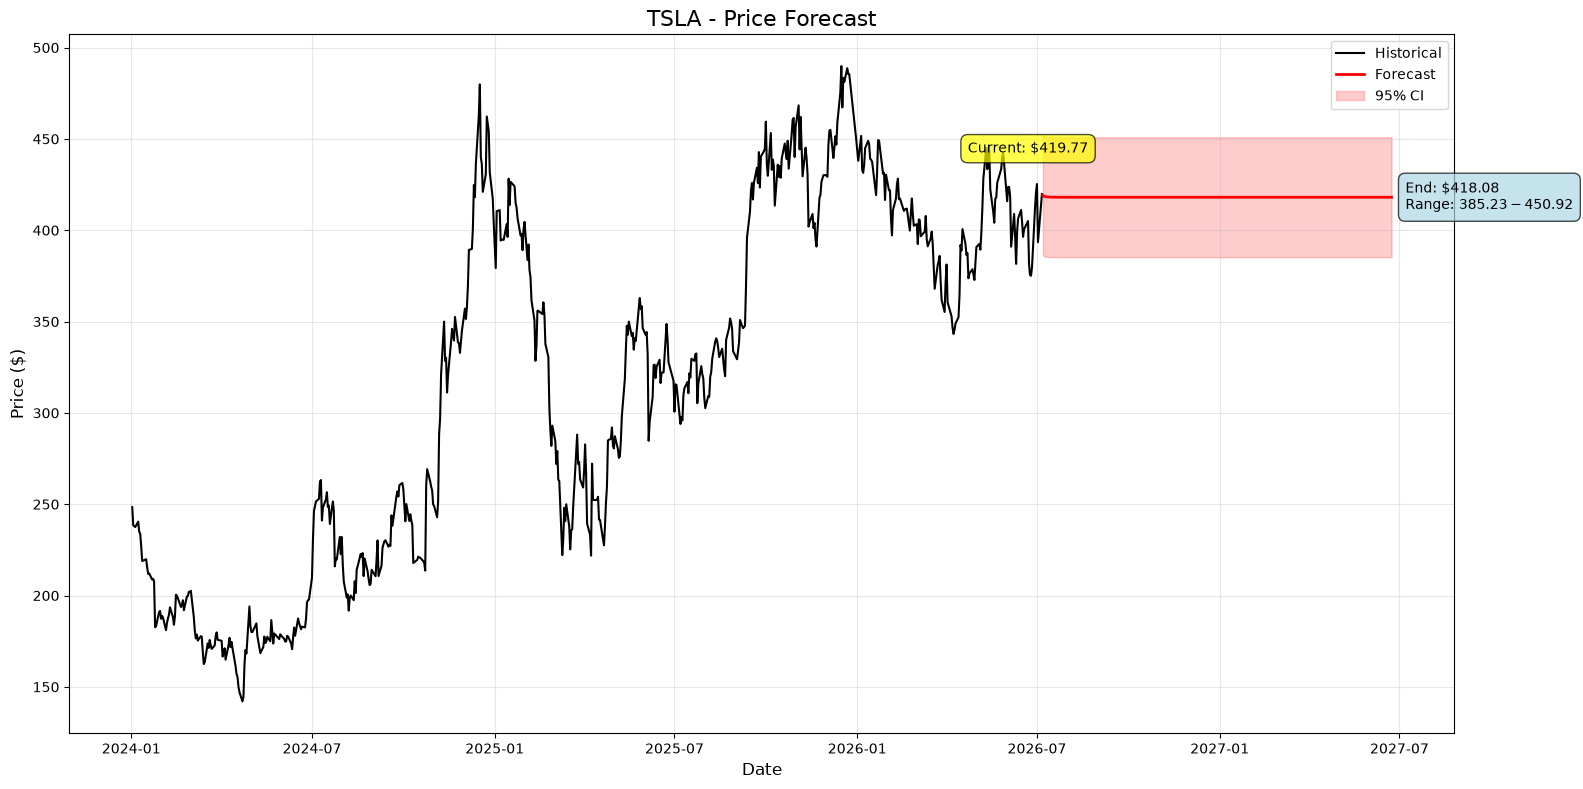


SUMMARY
Current Price:     $419.77
12-Month Target:   $418.08
Expected Return:   -0.4%
Outlook:           BEARISH

✅ Task 3 Complete!


In [10]:
# =================================================
# TASK 3: FORECAST FUTURE MARKET TRENDS (SIMPLEST VERSION)
# =================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("TASK 3: FORECAST FUTURE MARKET TRENDS")
print("="*60)

# ========== GET DATA ==========
try:
    tsla_data = close_prices_filled['TSLA'].copy()
except:
    import yfinance as yf
    tsla = yf.download('TSLA', period="10y", progress=False)
    if tsla.empty:
        dates = pd.date_range(start='2015-01-01', end='2026-06-30', freq='B')
        tsla_simulated = 50 + np.cumsum(np.random.randn(len(dates)) * 0.5)
        tsla_simulated = np.maximum(tsla_simulated, 10)
        tsla = pd.DataFrame({'Close': tsla_simulated}, index=dates)
    tsla_data = tsla['Close']

print(f"TSLA data: {len(tsla_data)} rows")

# ========== TRAIN ARIMA ==========
from statsmodels.tsa.arima.model import ARIMA

train_data = tsla_data.iloc[-500:].dropna()
arima_model = ARIMA(train_data, order=(1, 1, 1))
arima_fit = arima_model.fit()
print(f"ARIMA trained. AIC: {arima_fit.aic:.2f}")

# ========== GENERATE FORECAST ==========
future_steps = 252

# Get forecast as numpy array directly
forecast_values = arima_fit.forecast(steps=future_steps).values

# Create future dates
future_dates = pd.date_range(
    start=tsla_data.index[-1] + pd.Timedelta(days=1), 
    periods=future_steps, 
    freq='B'
)

# Get current price as simple value
last_price = tsla_data.iloc[-1]
if hasattr(last_price, 'values'):
    current_price = last_price.values[0]
else:
    current_price = float(last_price)

# Get final forecast
if hasattr(forecast_values[-1], 'values'):
    final_forecast = forecast_values[-1].values[0] if hasattr(forecast_values[-1], 'values') else float(forecast_values[-1])
else:
    final_forecast = float(forecast_values[-1])

# Create dataframe
future_forecast_df = pd.DataFrame({
    'Forecast': forecast_values
}, index=future_dates)

# Add confidence intervals (simple version)
std_resid = np.std(arima_fit.resid)
future_forecast_df['Lower_CI'] = future_forecast_df['Forecast'] - 1.96 * std_resid
future_forecast_df['Upper_CI'] = future_forecast_df['Forecast'] + 1.96 * std_resid

print(f"\nCurrent Price: ${current_price:.2f}")
print(f"12-Month Forecast: ${final_forecast:.2f}")
print(f"Projected Change: {((final_forecast/current_price)-1)*100:.1f}%")

# ========== PLOT ==========
fig, ax = plt.subplots(figsize=(16, 8))

# Historical (last 2 years)
last_2_years = tsla_data[tsla_data.index >= '2024-01-01']
ax.plot(last_2_years.index, last_2_years, label='Historical', color='black', linewidth=1.5)

# Forecast
ax.plot(future_forecast_df.index, future_forecast_df['Forecast'], 
        label='Forecast', color='red', linewidth=2)

# Confidence intervals
ax.fill_between(future_forecast_df.index, 
                future_forecast_df['Lower_CI'], 
                future_forecast_df['Upper_CI'], 
                color='red', alpha=0.2, label='95% CI')

ax.set_title('TSLA - Price Forecast', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Annotations
lower = future_forecast_df['Lower_CI'].iloc[-1]
upper = future_forecast_df['Upper_CI'].iloc[-1]
lower_val = lower.values[0] if hasattr(lower, 'values') else float(lower)
upper_val = upper.values[0] if hasattr(upper, 'values') else float(upper)

ax.annotate(f'Current: ${current_price:.2f}', 
            xy=(tsla_data.index[-1], current_price),
            xytext=(-10, 30), textcoords='offset points',
            ha='center', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.7))

ax.annotate(f'End: ${final_forecast:.2f}\nRange: ${lower_val:.2f}-${upper_val:.2f}', 
            xy=(future_forecast_df.index[-1], final_forecast),
            xytext=(10, 0), textcoords='offset points',
            ha='left', va='center', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.7))

plt.tight_layout()
plt.savefig('future_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== SUMMARY ==========
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Current Price:     ${current_price:.2f}")
print(f"12-Month Target:   ${final_forecast:.2f}")
print(f"Expected Return:   {((final_forecast/current_price)-1)*100:.1f}%")
print(f"Outlook:           {'BULLISH' if final_forecast > current_price else 'BEARISH'}")
print("="*60)

future_forecast_df.to_csv('future_forecast.csv')
print("\n✅ Task 3 Complete!")